In [1]:
import sys
from pathlib import Path

# notebooks → deep
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from envs.long_chain import LongChain
import matplotlib.pyplot as plt
from core.utils import load_run_data
from mail import email_pdf
plt.rcParams.update({
    'font.size': 8, 
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 12
})
# class EnvParams(environment.EnvParams):
#     chain_length: int = 200
#     fail_prob: float = 0.0  # Probability of random action (noise)
#     resample_init_pos: bool = False  # If True, start anywhere (Trajectory Stitching)
#     max_steps_in_episode: int = 500

PROJECT_ROOT: /usr/project/xtmp/ds541/td-avar-explore/deep
📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()


In [2]:
def plot_chain(run='3_13_lstd_rmax_no_s_prime/3_14_test', T_values=[0, 1,2,6, 10, 40, 60], SEED=0, title="Title"):
        # does the s' bonus lead to the exploding extrinsic value?
        # Intrinsic Reward

    config, metrics = load_run_data(run, 'Chain')

    n_rows = len(T_values)
    # Width 12 is a good balance for 1.3x linewidth overflow in Overleaf
    fig, axes = plt.subplots(n_rows, 3, figsize=(12, n_rows * 2.1), sharex=True)

    range_min, range_max = 0, None

    for row_idx, T in enumerate(T_values):
        # --- Row Header (Moved closer to the plot: xy changed from -0.5 to -0.25) ---
        last_10 = int(jnp.sum(metrics['visitation_count'][SEED][T][-11:]))
        axes[row_idx, 0].annotate(f"T={T}\nVis10={last_10}", 
                                    xy=(-0.25, 0.5), xycoords='axes fraction',
                                    fontsize=8, fontweight='bold', ha='right', va='center')
        
        # --- Col 1: Visitation & ri ---
        ax1 = axes[row_idx, 0]
        ax1t = ax1.twinx()
        p0, = ax1.plot(metrics['visitation_count'][SEED][T][range_min:range_max], color='black',  ls = '--' , label='Visits')
        p1, = ax1t.plot(metrics['ri_grid'][SEED][T][range_min:range_max], color='purple', lw=1.2, label='$r_i$')
        ax1.tick_params(axis='y', colors='black')
        ax1t.tick_params(axis='y', colors='purple')

        # --- Col 2: vi & vi_pred ---
        ax2 = axes[row_idx, 1]
        ax2t = ax2.twinx()
        p2, = ax2.plot(metrics['v_i'][SEED][T][range_min:range_max], color='blue', lw=1.5, label='True $v_i$')
        p3, = ax2t.plot(metrics['vi_pred'][SEED][T][range_min:range_max], color='blue', ls='--', alpha=0.6, label='Pred $v_i$')
        ax2.tick_params(axis='y', colors='blue')
        ax2t.tick_params(axis='y', colors='blue')

        # --- Col 3: ve & ve_pred ---
        ax3 = axes[row_idx, 2]
        ax3t = ax3.twinx()
        p4, = ax3.plot(metrics['v_e'][SEED][T][range_min:range_max], color='red', lw=1.5, label='True $v_e$')
        p5, = ax3t.plot(metrics['v_e_pred'][SEED][T][range_min:range_max], color='red', ls='--', alpha=0.6, label='Pred $v_e$')
        ax3.tick_params(axis='y', colors='red')
        ax3t.tick_params(axis='y', colors='red')

        # --- Column labels (a), (b), (c) on the top row ---
        if row_idx == 0:
            ax1.set_title("(a) Visitation & $r_i$", pad=10)
            ax2.set_title("(b) Intrinsic $V_i$", pad=10)
            ax3.set_title("(c) Extrinsic $V_e$", pad=10)
            
            # Unified Legend
            fig.legend(handles=[p0, p1, p2, p3, p4, p5], 
                    loc='upper center', bbox_to_anchor=(0.5, 0.98),
                    ncol=6, frameon=False, fontsize=9)

        for ax in [ax1, ax2, ax3]:
            ax.grid(True, alpha=0.15, ls='-')
            ax.spines['top'].set_visible(False)

    # X-axis label on bottom row
    for ax in axes[-1]:
        ax.set_xlabel('State Index')
    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.99)
    # Reduced the left margin (rect[SEED] changed from 0.08 to 0.05)
    plt.tight_layout(rect=[0.05, 0, 1, 0.95])

    # Use bbox_inches='tight' to ensure the PDF is cropped right to the edge of the labels
    # plt.savefig('/Users/dillonsandhu/Documents/Research/bayesian-rl/deep/figures/200-chain-no-warmup.pdf', bbox_inches='tight')
    plt.show()

    for i in range(4):
        plt.plot(metrics['returned_discounted_episode_returns'][i])
    plt.show()
    return fig

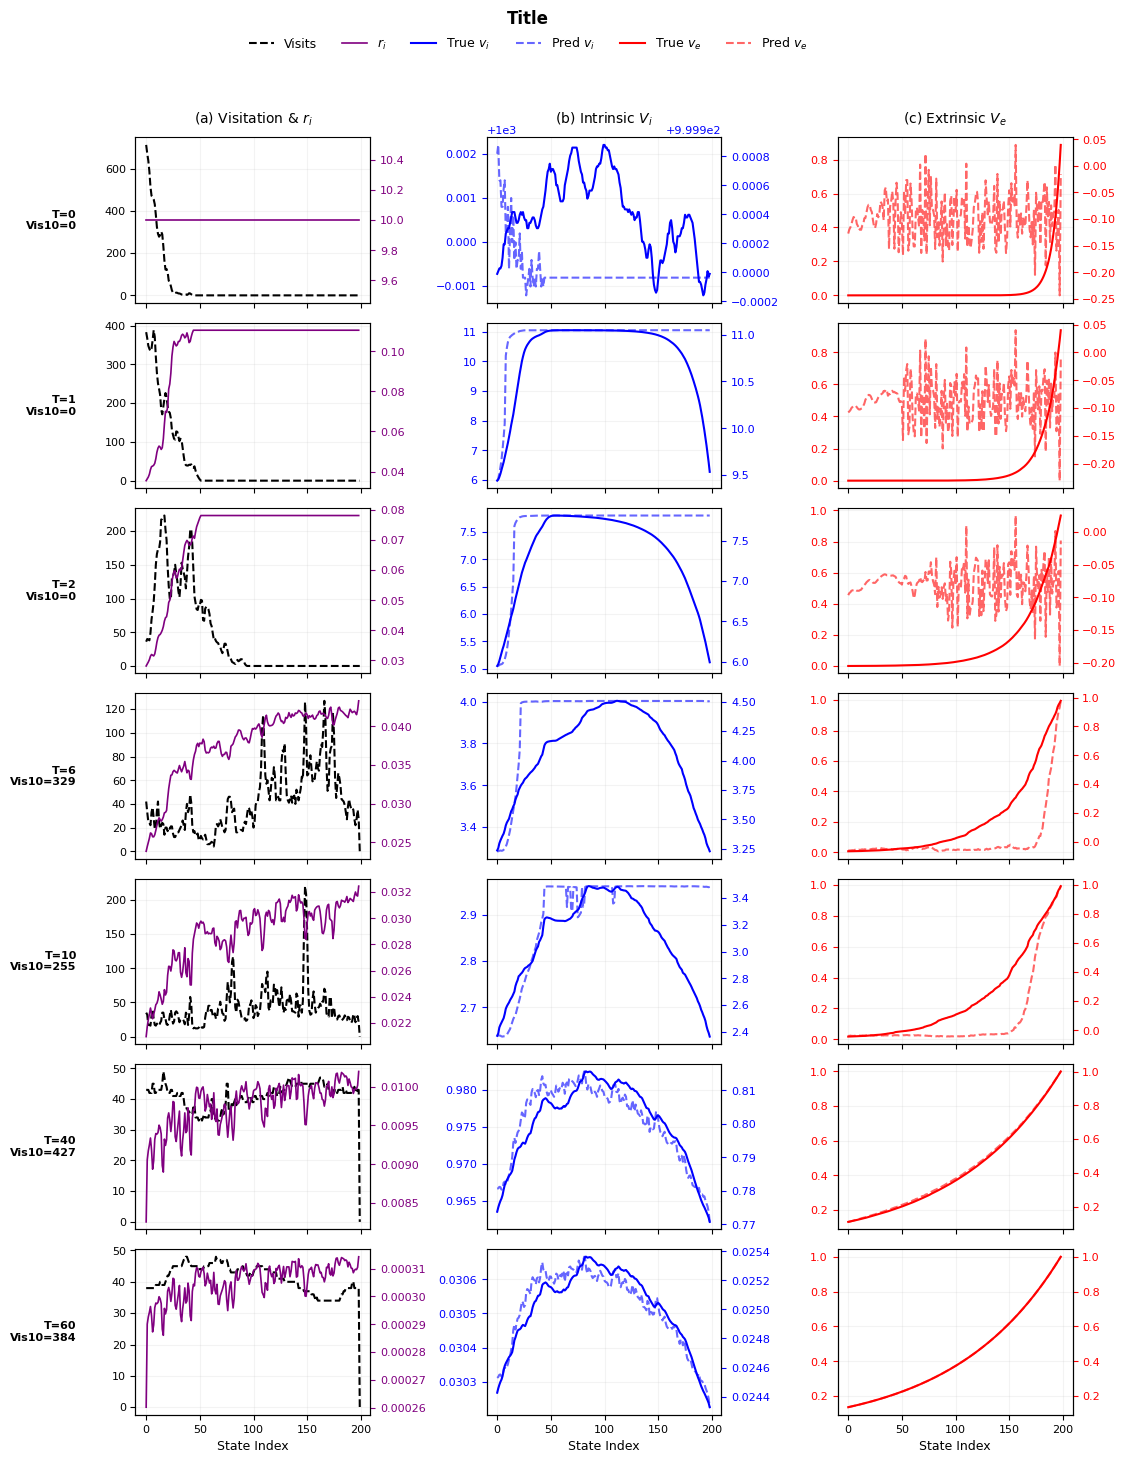

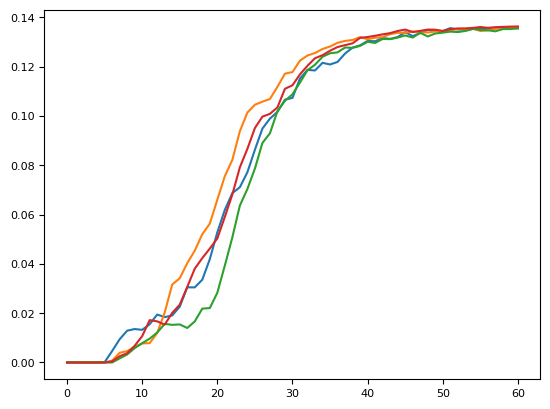

In [9]:
# LSTD
fig = plot_chain('3_18_cov_lstd/cont_opt_init',SEED=1)


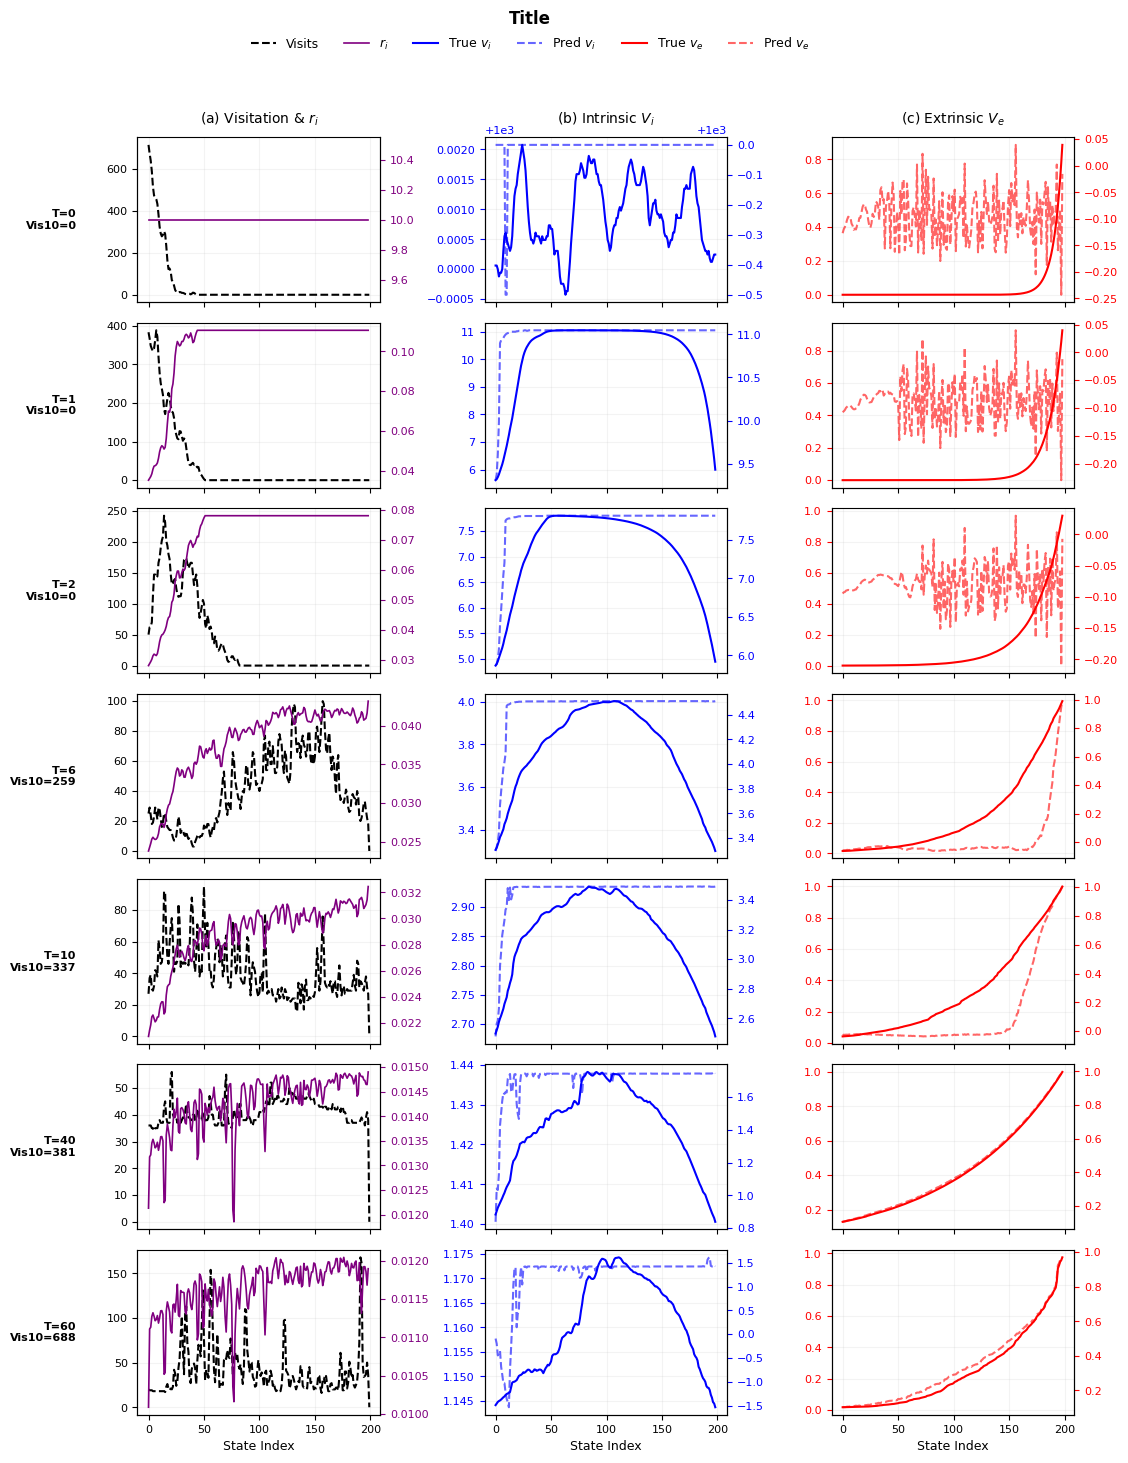

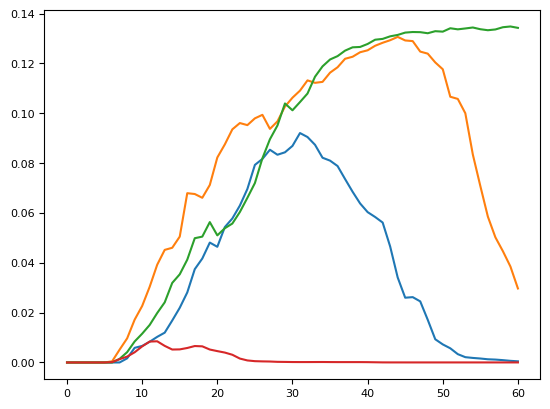

In [7]:
# LSPI
fig = plot_chain('3_23_cov_lspi/cont_opt_init',SEED=1)


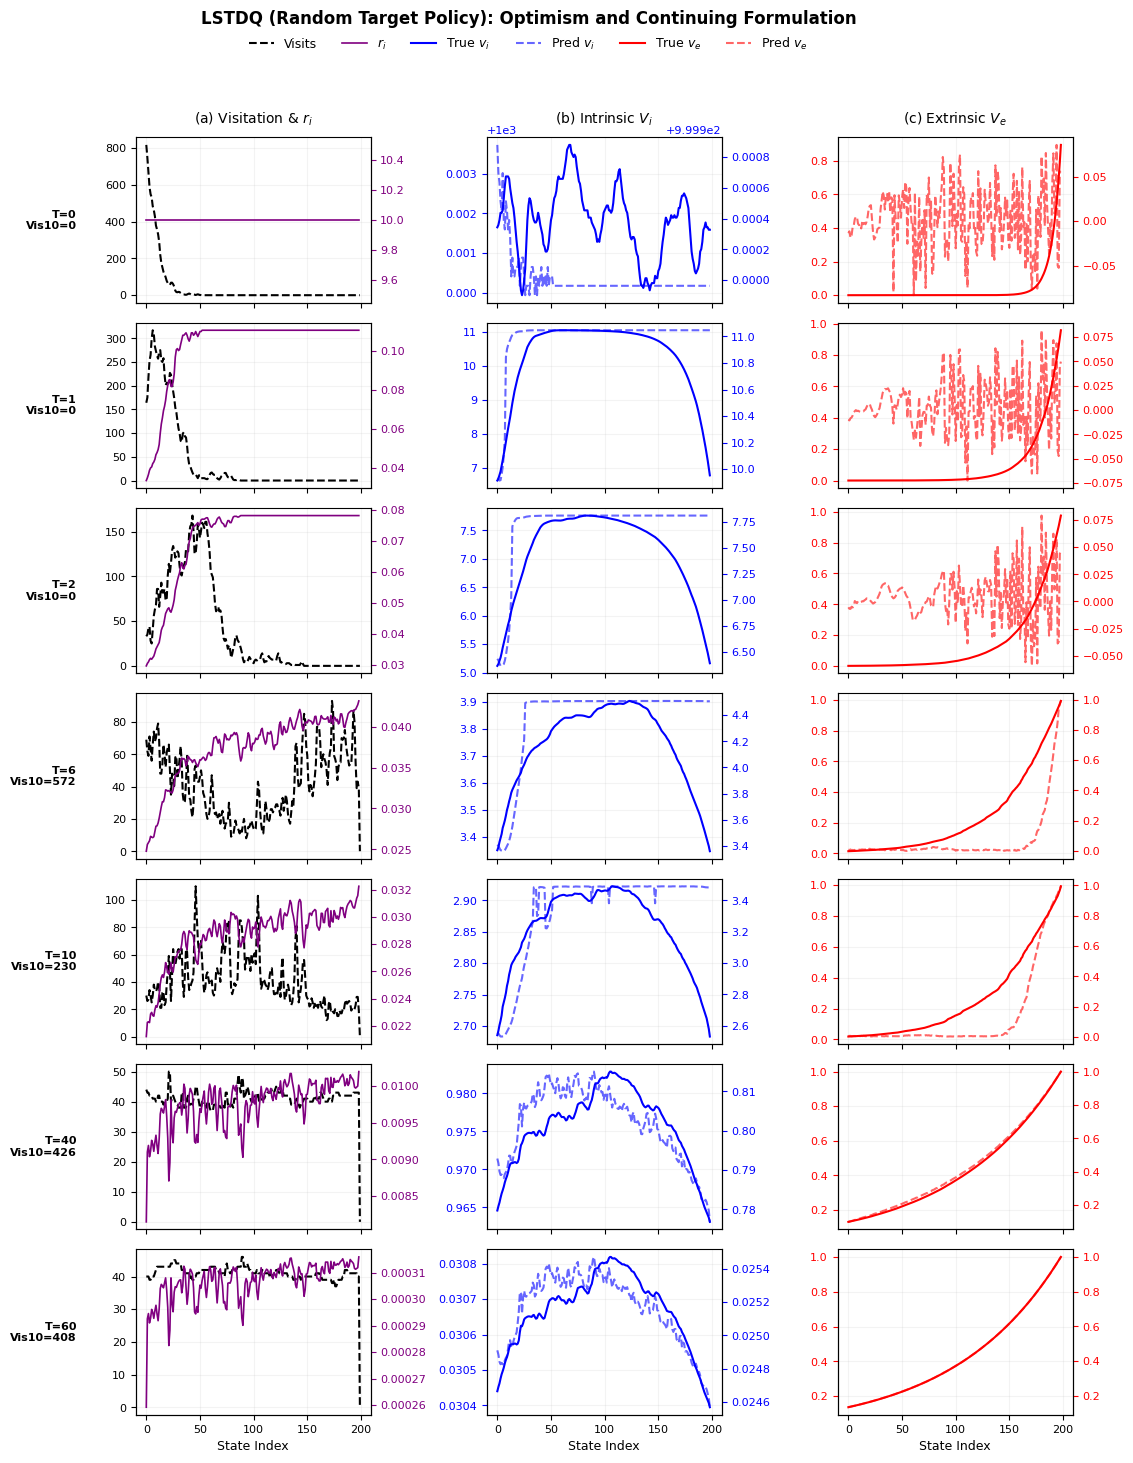

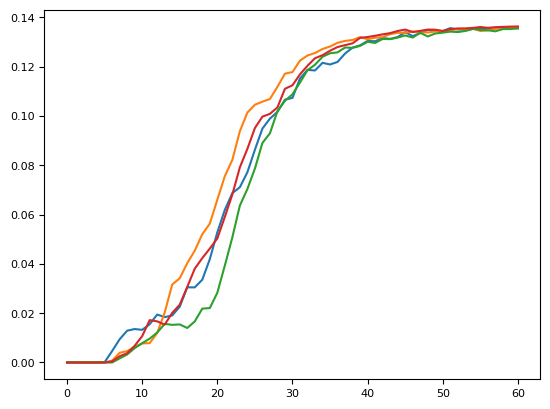

In [4]:

fig = plot_chain('3_18_cov_lstd/cont_opt_init', title="LSTDQ (Random Target Policy): Optimism and Continuing Formulation")

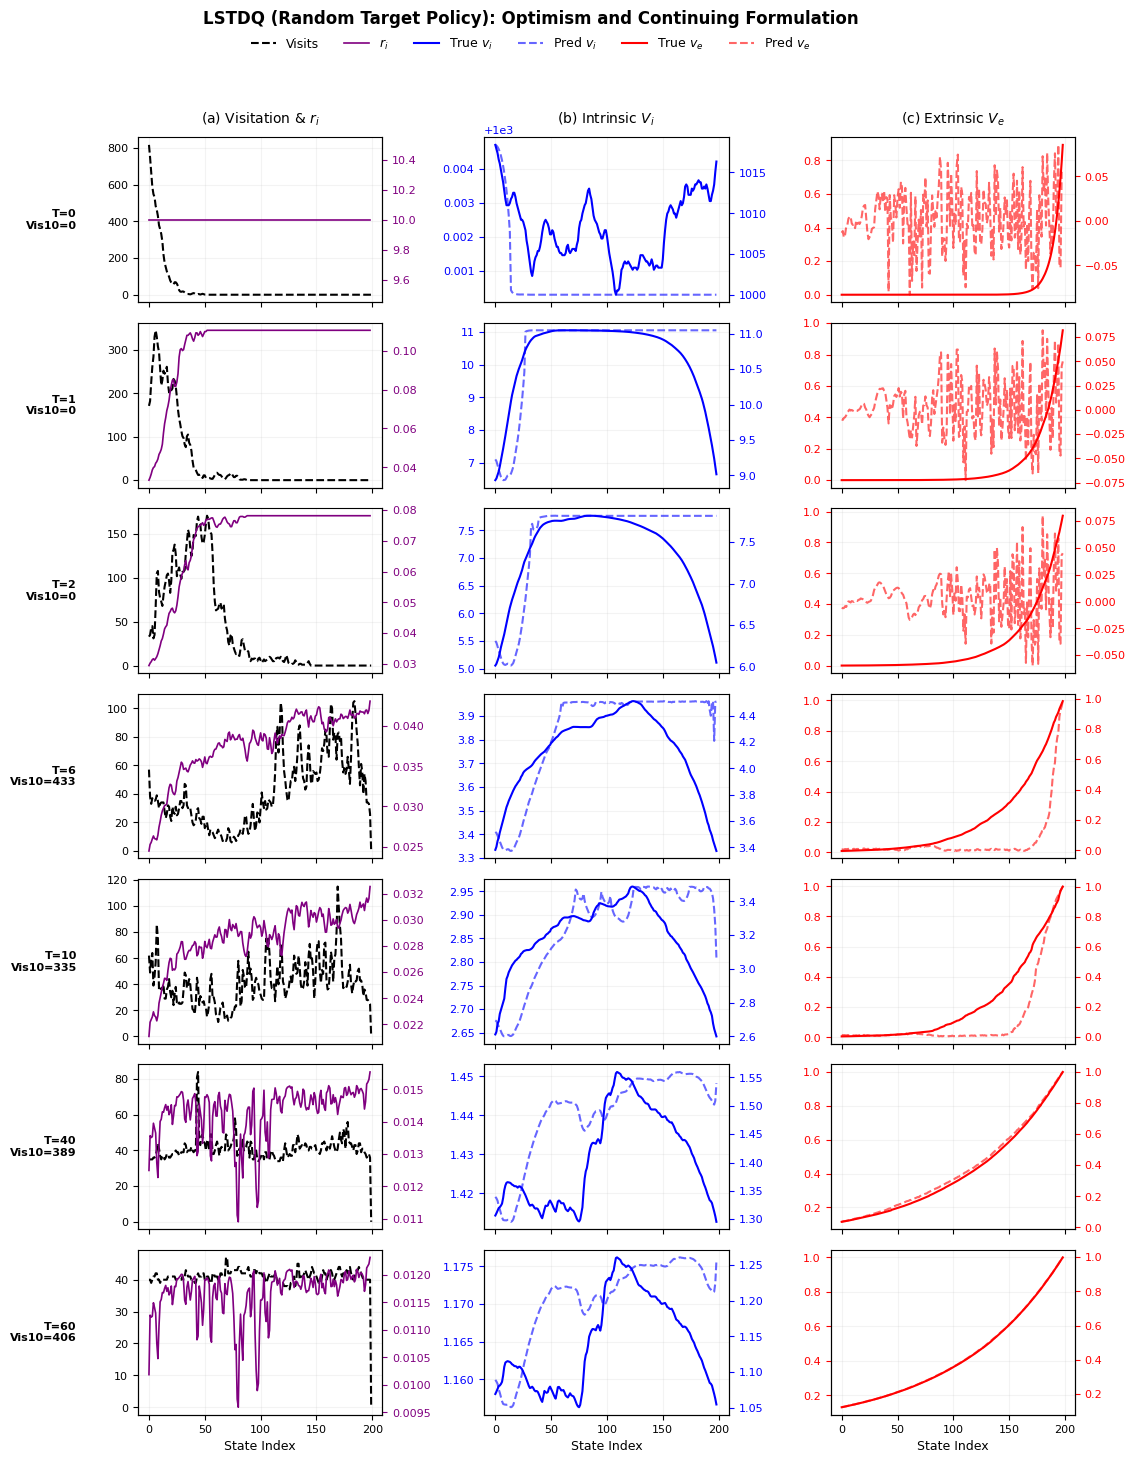

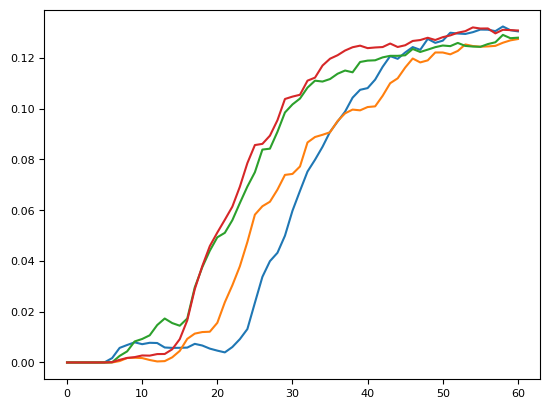

📁 Found ../figures/lstdq_cont_chain.pdf (83.1 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [ ]:
# LSTD-Q
# continuing + optimism
fig = plot_chain('3_23_cov_lstd_q/20260324_090733', title="LSTDQ (Random Target Policy): Optimism and Continuing Formulation")
# fig.savefig('../figures/lstdq_cont_chain.pdf', bbox_inches='tight', dpi=300)
# email_pdf('../figures/lstdq_cont_chain.pdf')

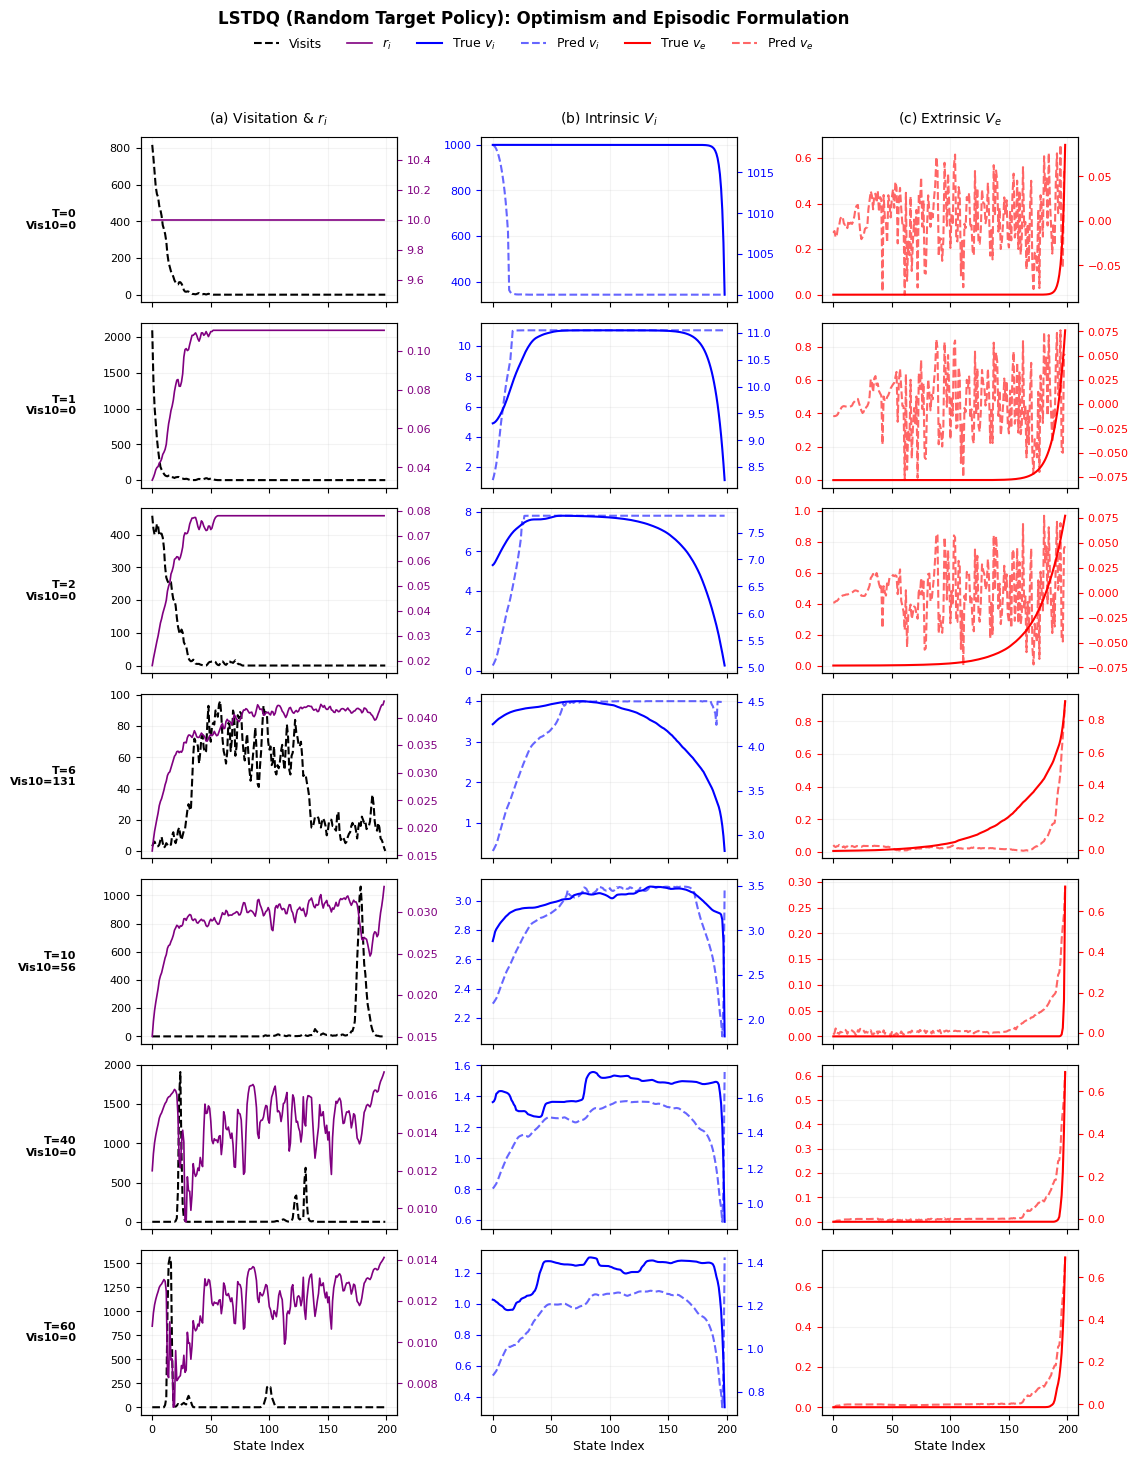

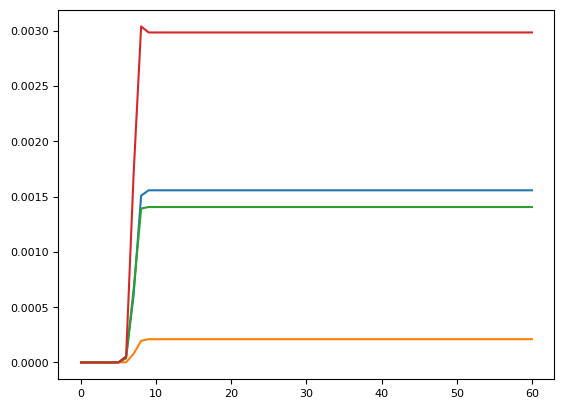

📁 Found ../figures/lstdq_ep_chain.pdf (73.3 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [22]:
# LSTD-Q
# episodic + optimism
fig = plot_chain('3_23_cov_lstd_q/20260324_090324', title="LSTDQ (Random Target Policy): Optimism and Episodic Formulation")
fig.savefig('../figures/lstdq_ep_chain.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/lstdq_ep_chain.pdf')

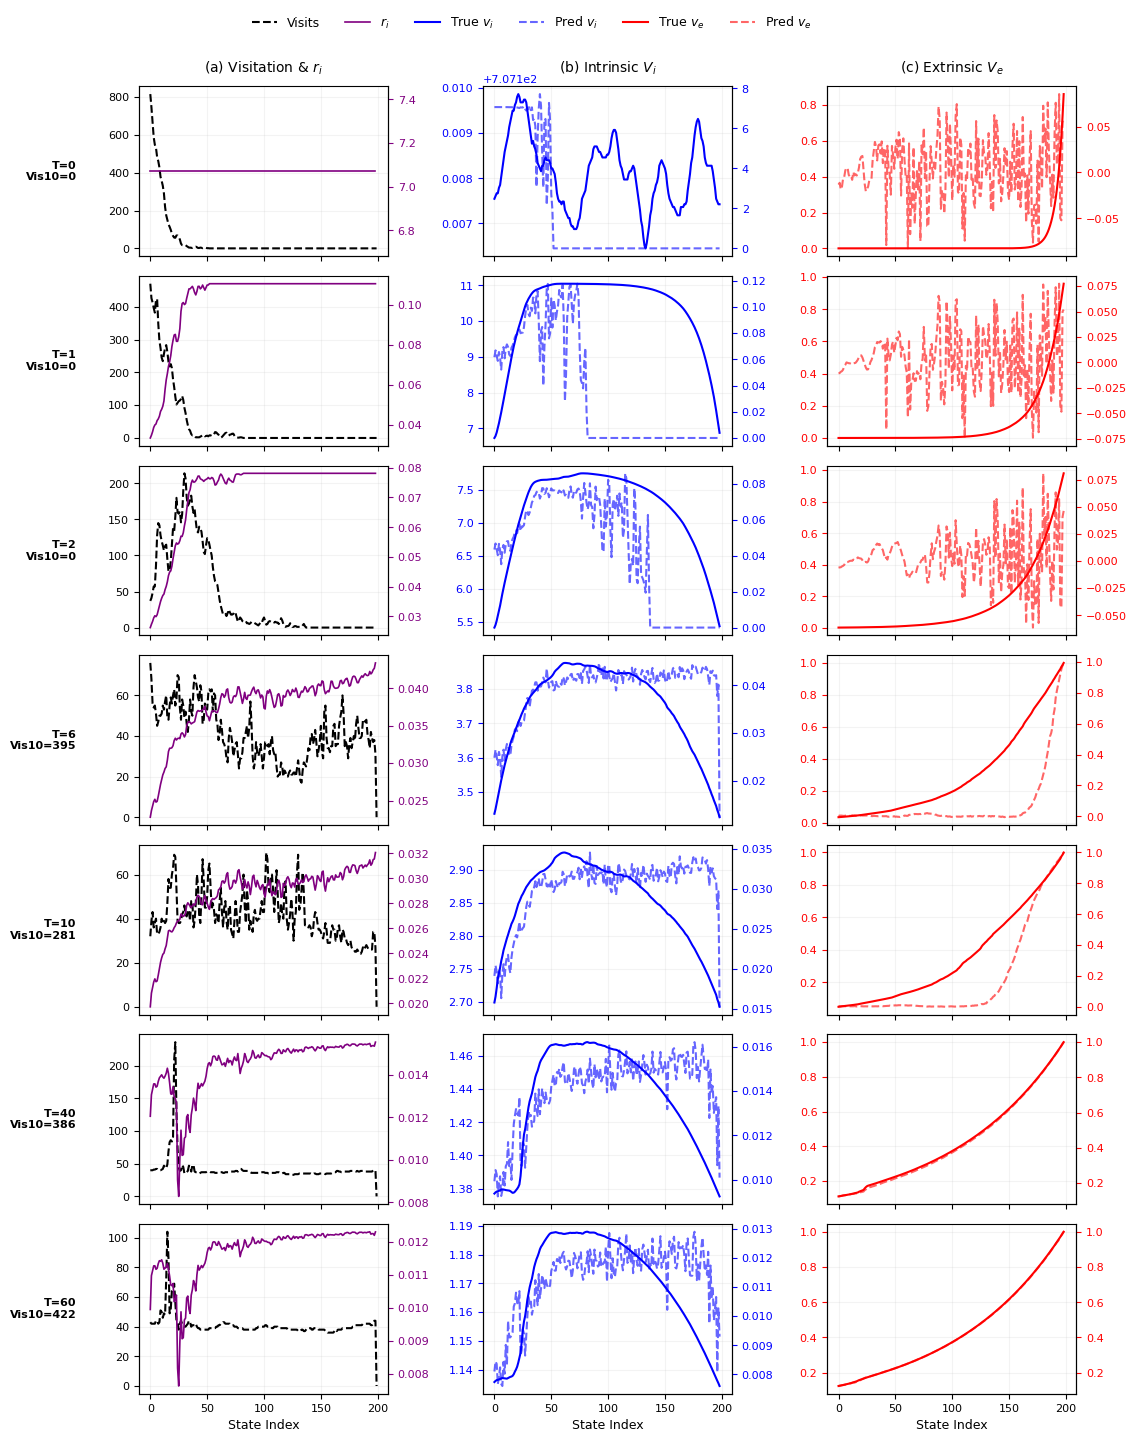

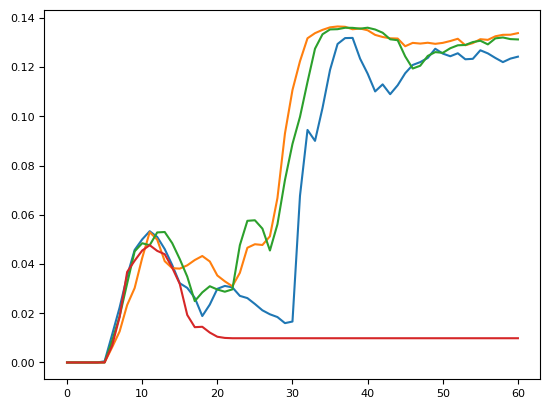

In [11]:
# LSTD-Q
fig = plot_chain('3_23_cov_lstd_q/cont')
